# XGBOOST — Prediksi Kelulusan Mahasiswa

Notebook ini membangun model **XGBoost Classifier** untuk memprediksi status kelulusan mahasiswa berdasarkan berbagai fitur akademik.

## 1. Install & Import Library

In [1]:
# Install xgboost jika belum tersedia
!pip install xgboost

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from xgboost import XGBClassifier, plot_importance
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

import warnings
warnings.filterwarnings('ignore')

print('Library berhasil diimport!')

Library berhasil diimport!


## 2. Load Dataset

In [3]:
# Jika menggunakan Google Colab, mount drive terlebih dahulu:
# from google.colab import drive
# drive.mount('/content/drive')
# df = pd.read_csv('/content/drive/MyDrive/dataset_kelulusan_mahasiswa.csv')

df = pd.read_csv('/root/perkuliahan/ml/dataset/dataset_kelulusan_mahasiswa.csv')
print('Dataset berhasil dimuat!')
df.head()

Dataset berhasil dimuat!


,IPK,Mata Kuliah Tidak Lulus,Jumlah Cuti Akademik,Pekerjaan Sambil Kuliah,Jumlah Semester,Status Kelulusan,IPS Rata-rata,IPS Semester Akhir,IPS Tren,Kategori Kehadiran
0,3.87,5,1,Ya,13,1,3.299231,2.66,0.57,Sedang
1,3.65,5,1,Tidak,12,0,3.069167,3.56,1.21,Rendah
2,3.57,2,2,Tidak,11,1,2.955455,2.89,-0.59,Tinggi
3,3.96,0,1,Tidak,12,0,3.230833,2.63,-1.34,Rendah
4,2.27,0,0,Ya,9,1,3.066667,2.22,-1.14,Sedang


## 3. Eksplorasi Data (EDA)

In [4]:
# Dimensi dataset
print('Jumlah baris dan kolom:', df.shape)

Jumlah baris dan kolom: (100000, 10)


In [5]:
# Tipe data tiap kolom
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 10 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   IPK                      100000 non-null  float64
 1   Mata Kuliah Tidak Lulus  100000 non-null  int64  
 2   Jumlah Cuti Akademik     100000 non-null  int64  
 3   Pekerjaan Sambil Kuliah  100000 non-null  str    
 4   Jumlah Semester          100000 non-null  int64  
 5   Status Kelulusan         100000 non-null  int64  
 6   IPS Rata-rata            100000 non-null  float64
 7   IPS Semester Akhir       100000 non-null  float64
 8   IPS Tren                 100000 non-null  float64
 9   Kategori Kehadiran       100000 non-null  str    
dtypes: float64(4), int64(4), str(2)
memory usage: 7.6 MB


In [6]:
# Statistik deskriptif
df.describe()

,IPK,Mata Kuliah Tidak Lulus,Jumlah Cuti Akademik,Jumlah Semester,Status Kelulusan,IPS Rata-rata,IPS Semester Akhir,IPS Tren
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,2.999246,2.498990,0.999500,10.502560,0.499620,3.000592,2.998107,-0.002869
std,0.576973,1.707802,0.817158,2.283617,0.500002,0.182873,0.578035,0.816913
min,2.000000,0.000000,0.000000,7.000000,0.000000,2.234286,2.000000,-2.000000
25%,2.500000,1.000000,0.000000,9.000000,0.000000,2.878000,2.500000,-0.590000
50%,3.000000,2.000000,1.000000,10.000000,0.000000,3.000833,3.000000,0.000000
75%,3.500000,4.000000,2.000000,12.000000,1.000000,3.123750,3.500000,0.580000
max,4.000000,5.000000,2.000000,14.000000,1.000000,3.754286,4.000000,1.990000


In [7]:
# Cek missing values
print('Missing values per kolom:')
print(df.isnull().sum())

Missing values per kolom:
IPK                        0
Mata Kuliah Tidak Lulus    0
Jumlah Cuti Akademik       0
Pekerjaan Sambil Kuliah    0
Jumlah Semester            0
Status Kelulusan           0
IPS Rata-rata              0
IPS Semester Akhir         0
IPS Tren                   0
Kategori Kehadiran         0
dtype: int64


Distribusi Status Kelulusan:
Status Kelulusan
0    50038
1    49962
Name: count, dtype: int64

Status Kelulusan
0    50.0%
1    50.0%
Name: proportion, dtype: str


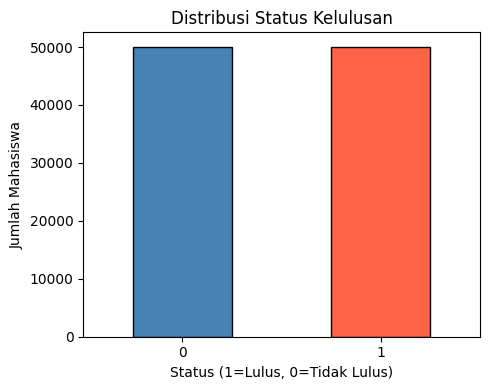

In [8]:
# Distribusi target (Status Kelulusan)
print('Distribusi Status Kelulusan:')
print(df['Status Kelulusan'].value_counts())
print()
print(df['Status Kelulusan'].value_counts(normalize=True).map(lambda x: f'{x:.1%}'))

plt.figure(figsize=(5, 4))
df['Status Kelulusan'].value_counts().plot(kind='bar', color=['steelblue', 'tomato'], edgecolor='black')
plt.title('Distribusi Status Kelulusan')
plt.xlabel('Status (1=Lulus, 0=Tidak Lulus)')
plt.ylabel('Jumlah Mahasiswa')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

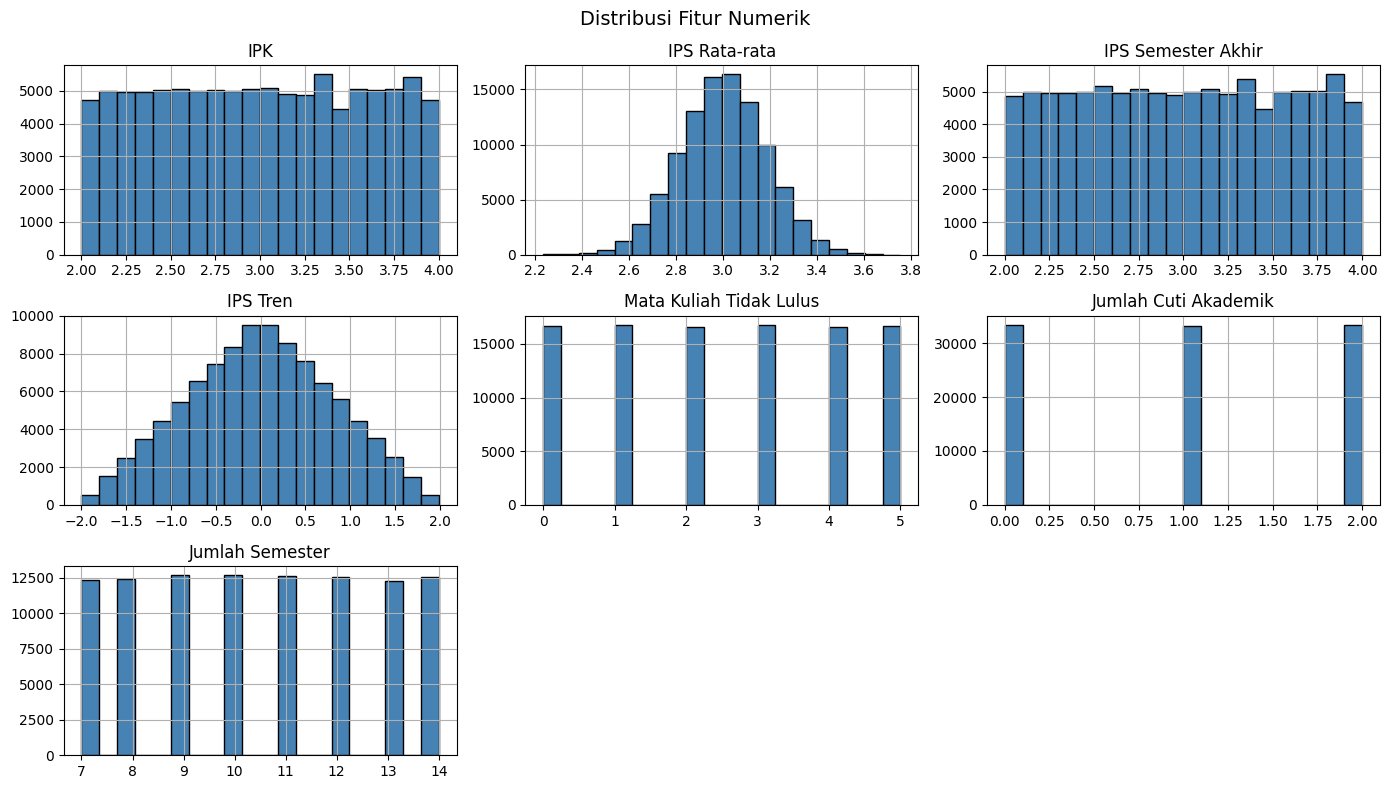

In [9]:
# Distribusi fitur numerik
numerik = ['IPK', 'IPS Rata-rata', 'IPS Semester Akhir', 'IPS Tren',
           'Mata Kuliah Tidak Lulus', 'Jumlah Cuti Akademik', 'Jumlah Semester']

df[numerik].hist(bins=20, figsize=(14, 8), color='steelblue', edgecolor='black')
plt.suptitle('Distribusi Fitur Numerik', fontsize=14)
plt.tight_layout()
plt.show()

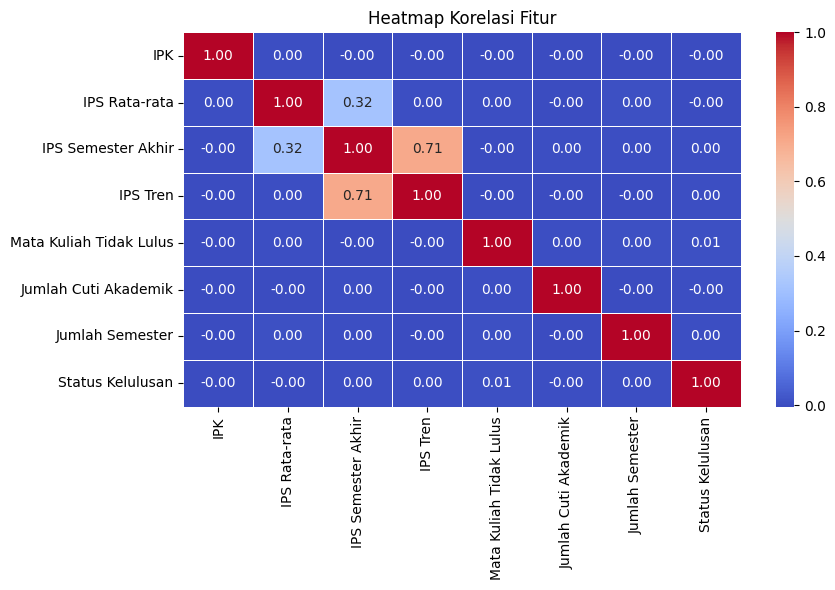

In [10]:
# Korelasi antar fitur numerik
plt.figure(figsize=(9, 6))
corr = df[numerik + ['Status Kelulusan']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Heatmap Korelasi Fitur')
plt.tight_layout()
plt.show()

## 4. Preprocessing Data

In [11]:
# Encode kolom kategorikal
d_pekerjaan = {'Ya': 1, 'Tidak': 0}
df['Pekerjaan Sambil Kuliah'] = df['Pekerjaan Sambil Kuliah'].map(d_pekerjaan)

d_kehadiran = {'Rendah': 0, 'Sedang': 1, 'Tinggi': 2}
df['Kategori Kehadiran'] = df['Kategori Kehadiran'].map(d_kehadiran)

print('Encoding selesai. Contoh data:')
df.head()

Encoding selesai. Contoh data:


,IPK,Mata Kuliah Tidak Lulus,Jumlah Cuti Akademik,Pekerjaan Sambil Kuliah,Jumlah Semester,Status Kelulusan,IPS Rata-rata,IPS Semester Akhir,IPS Tren,Kategori Kehadiran
0,3.87,5,1,1,13,1,3.299231,2.66,0.57,1
1,3.65,5,1,0,12,0,3.069167,3.56,1.21,0
2,3.57,2,2,0,11,1,2.955455,2.89,-0.59,2
3,3.96,0,1,0,12,0,3.230833,2.63,-1.34,0
4,2.27,0,0,1,9,1,3.066667,2.22,-1.14,1


In [12]:
# Pisahkan fitur (X) dan target (y)
features = [
    'IPK', 'Mata Kuliah Tidak Lulus', 'Jumlah Cuti Akademik',
    'Pekerjaan Sambil Kuliah', 'Jumlah Semester',
    'IPS Rata-rata', 'IPS Semester Akhir', 'IPS Tren',
    'Kategori Kehadiran'
]

X = df[features]
y = df['Status Kelulusan']

print('Jumlah fitur:', X.shape[1])
print('Jumlah data :', X.shape[0])

Jumlah fitur: 9
Jumlah data : 100000


## 5. Split Data (Train & Test)

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      # 80% train, 20% test
    random_state=42,    # agar hasil dapat direproduksi
    stratify=y          # menjaga proporsi kelas tetap seimbang
)

print(f'Data latih : {X_train.shape[0]} baris')
print(f'Data uji   : {X_test.shape[0]} baris')

Data latih : 80000 baris
Data uji   : 20000 baris


## 6. Membuat & Melatih Model XGBoost

In [14]:
xgb_model = XGBClassifier(
    n_estimators=200,        # jumlah pohon
    max_depth=6,             # kedalaman maksimal tiap pohon
    learning_rate=0.1,       # kecepatan belajar (semakin kecil semakin teliti)
    subsample=0.8,           # proporsi data yang dipakai tiap iterasi
    colsample_bytree=0.8,    # proporsi fitur yang dipakai tiap pohon
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)

xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],  # pantau performa di data uji selama training
    verbose=50                    # tampilkan log setiap 50 iterasi
)

print('\nModel berhasil dilatih!')

[0]	validation_0-logloss:0.69313
[50]	validation_0-logloss:0.69576
[100]	validation_0-logloss:0.69792
[150]	validation_0-logloss:0.69934
[199]	validation_0-logloss:0.70102

Model berhasil dilatih!


## 7. Evaluasi Model

In [15]:
# Prediksi pada data uji
y_pred = xgb_model.predict(X_test)

# Akurasi
akurasi = accuracy_score(y_test, y_pred)
print(f'Akurasi Model: {akurasi:.4f} ({akurasi*100:.2f}%)')

Akurasi Model: 0.4935 (49.35%)


In [16]:
# Classification Report (Precision, Recall, F1-Score)
print('Classification Report:')
print(classification_report(y_test, y_pred, target_names=['Tidak Lulus', 'Lulus']))

Classification Report:
              precision    recall  f1-score   support

 Tidak Lulus       0.49      0.50      0.50     10008
       Lulus       0.49      0.48      0.49      9992

    accuracy                           0.49     20000
   macro avg       0.49      0.49      0.49     20000
weighted avg       0.49      0.49      0.49     20000



<Figure size 600x500 with 0 Axes>

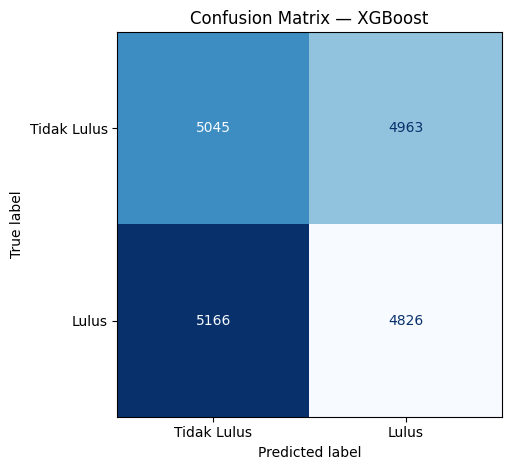

In [17]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Tidak Lulus', 'Lulus'])
disp.plot(cmap='Blues', colorbar=False)
plt.title('Confusion Matrix — XGBoost')
plt.tight_layout()
plt.show()

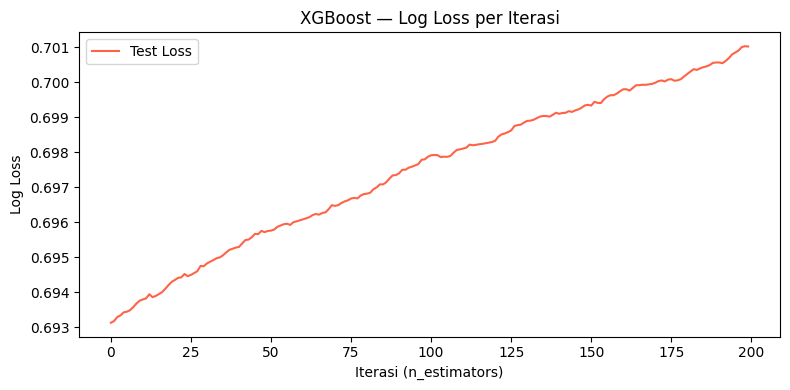

In [18]:
# Kurva Loss selama Training vs Testing
results = xgb_model.evals_result()

plt.figure(figsize=(8, 4))
plt.plot(results['validation_0']['logloss'], label='Test Loss', color='tomato')
plt.title('XGBoost — Log Loss per Iterasi')
plt.xlabel('Iterasi (n_estimators)')
plt.ylabel('Log Loss')
plt.legend()
plt.tight_layout()
plt.show()

## 8. Feature Importance

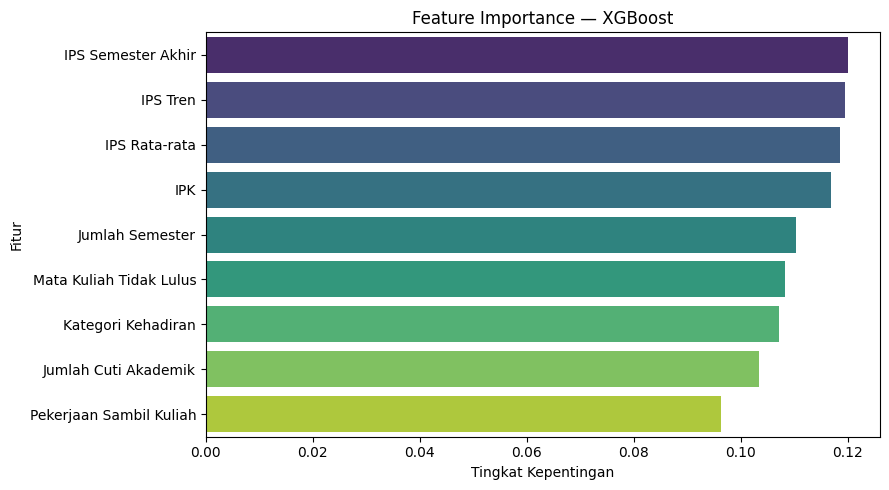

                  Fitur  Importance
     IPS Semester Akhir    0.120000
               IPS Tren    0.119424
          IPS Rata-rata    0.118439
                    IPK    0.116822
        Jumlah Semester    0.110386
Mata Kuliah Tidak Lulus    0.108242
     Kategori Kehadiran    0.107092
   Jumlah Cuti Akademik    0.103404
Pekerjaan Sambil Kuliah    0.096189


In [19]:
# Fitur mana yang paling berpengaruh?
importances = xgb_model.feature_importances_
feat_df = pd.DataFrame({
    'Fitur': features,
    'Importance': importances
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(9, 5))
sns.barplot(data=feat_df, x='Importance', y='Fitur', palette='viridis')
plt.title('Feature Importance — XGBoost')
plt.xlabel('Tingkat Kepentingan')
plt.tight_layout()
plt.show()

print(feat_df.to_string(index=False))

## 9. Prediksi Data Baru

In [20]:
# Contoh data mahasiswa baru
# Urutan: IPK, MK Tidak Lulus, Cuti, Pekerjaan, Semester, IPS Rata, IPS Akhir, IPS Tren, Kehadiran
data_baru = pd.DataFrame([{
    'IPK': 3.5,
    'Mata Kuliah Tidak Lulus': 1,
    'Jumlah Cuti Akademik': 0,
    'Pekerjaan Sambil Kuliah': 0,   # 0 = Tidak, 1 = Ya
    'Jumlah Semester': 8,
    'IPS Rata-rata': 3.4,
    'IPS Semester Akhir': 3.6,
    'IPS Tren': 0.3,
    'Kategori Kehadiran': 2          # 0=Rendah, 1=Sedang, 2=Tinggi
}])

# Prediksi
hasil = xgb_model.predict(data_baru)[0]
probabilitas = xgb_model.predict_proba(data_baru)[0]

label = 'LULUS' if hasil == 1 else 'TIDAK LULUS'
print(f'Hasil Prediksi           : {label}')
print(f'Probabilitas Tidak Lulus : {probabilitas[0]:.2%}')
print(f'Probabilitas Lulus       : {probabilitas[1]:.2%}')

Hasil Prediksi           : TIDAK LULUS
Probabilitas Tidak Lulus : 55.31%
Probabilitas Lulus       : 44.69%
